In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import seaborn as sns
import matplotlib.pyplot as plt
from yellowbrick.cluster import KElbowVisualizer
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import joblib

# 1 Cargamos el conjunto  de datos

In [4]:
df=pd.read_csv('https://breathecode.herokuapp.com/asset/internal-link?id=809&path=housing.csv')
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


# Train test split

In [5]:
# Dejamos un df solo con las columnas que nos interesa y que nos indica el ejercicio
df1=df[['MedInc','Latitude','Longitude']]
# sobre este aplicamos el train test split
X_train, X_test = train_test_split(df1, test_size=0.2, random_state=42)

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Importante, se escalan los datos, porque si bien latitude y longitude manejan la misma "escala" MedInc  los datos son muchos mas pequeños y estos se podrian ver afectados por esto.

# Construimos el K-means

## Metodo Distorcion Score

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

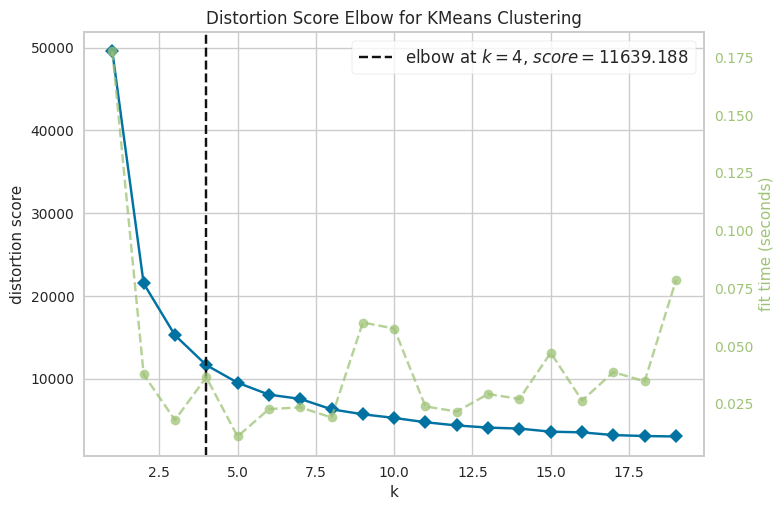

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [7]:
kmeans = KMeans()

elbow_visualizer = KElbowVisualizer(kmeans, k=(1,20))
elbow_visualizer.fit(X_train_scaled)
elbow_visualizer.show()

## Metodo silhouette_scores

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

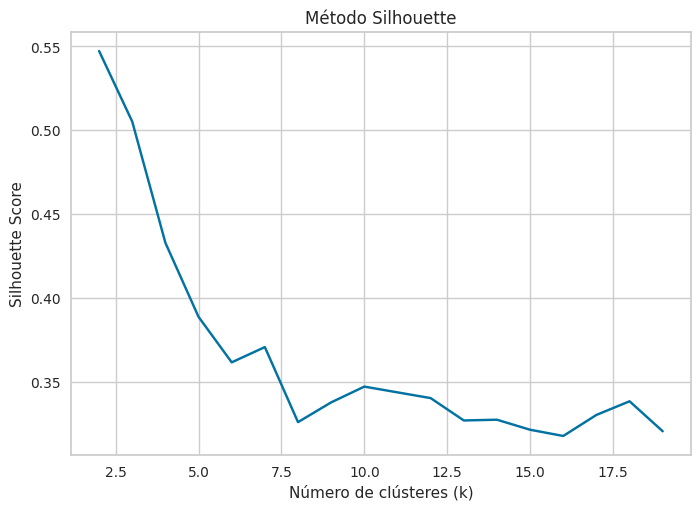

In [8]:
silhouette_scores = []

for k in range(2, 20):
    kmeans = KMeans(n_clusters=k).fit(X_train_scaled)
    clusters = kmeans.predict(X_train_scaled)
    silhouette_scores.append(silhouette_score(X_train_scaled, clusters))

plt.plot(range(2, 20), silhouette_scores)
plt.xlabel('Número de clústeres (k)')
plt.ylabel('Silhouette Score')
plt.title('Método Silhouette')
plt.show()

## Método Davies Bouldin

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

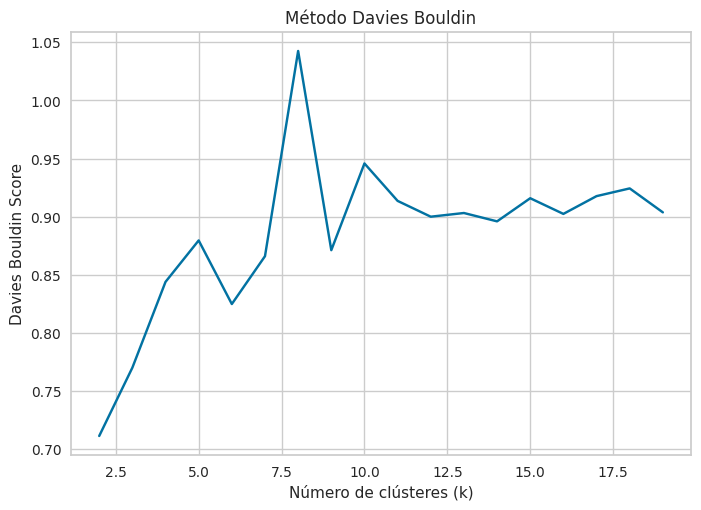

In [9]:
db_scores = []

for k in range(2, 20):
    kmeans = KMeans(n_clusters=k).fit(X_train_scaled)
    clusters = kmeans.predict(X_train_scaled)
    db_scores.append(davies_bouldin_score(X_train_scaled, clusters))

plt.plot(range(2, 20), db_scores)
plt.xlabel('Número de clústeres (k)')
plt.ylabel('Davies Bouldin Score')
plt.title('Método Davies Bouldin')
plt.show()

## Agregamos la columna Cluster y graficamos

De acuerdo a lo anterior tenemos que K=2 por ende habria 2 CLusters, sin embargo por motivos del ejercicio tomamos K=6

In [10]:
# Asignamos los clusters a los datos Train
kmeans = KMeans(n_clusters=6, random_state=42)
kmeans.fit(X_train_scaled)
X_train['cluster'] = kmeans.labels_
#  Asignamos la predicion de los clusters a los datos Test
test_clusters = kmeans.predict(X_test_scaled)
X_test['cluster'] = test_clusters

### Graficamos los datos de Tran como los datos de test

<Axes: xlabel='Longitude', ylabel='Latitude'>

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

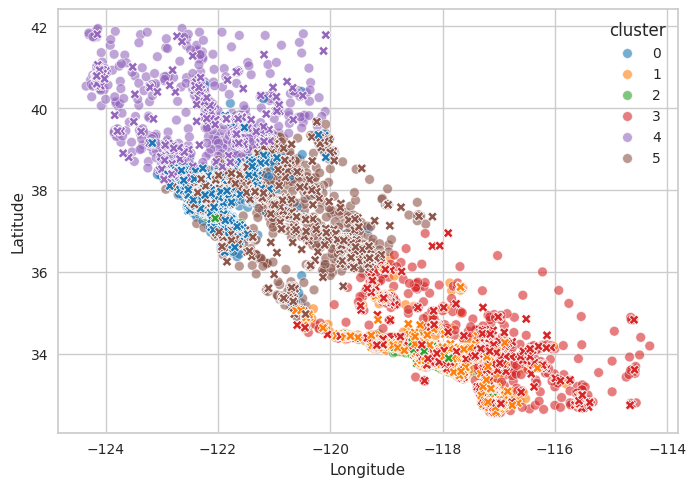

In [11]:

sns.scatterplot(
    data=X_train,
    x='Longitude',
    y='Latitude',
    hue='cluster',  
    palette='tab10',
    alpha=0.6
)

sns.scatterplot(
    data=X_test,
    x='Longitude',
    y='Latitude',
    hue='cluster',
    palette='tab10',
    marker='X',   
    legend=False  
)

Al analizar los datos podemos ver que en su gran mayoria los datos de test se encuentran al cluster que corresponden, sin embargo es normal que varios clusters esten superpuestos, ya que por motivos de ejercicio se escogio K=6 en vez de K=2 que era lo que nos siguerian el metodo Método Davies Bouldin y el Método Silhouette, miremos como nos daria si este fuera K=2

<Axes: xlabel='Longitude', ylabel='Latitude'>

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

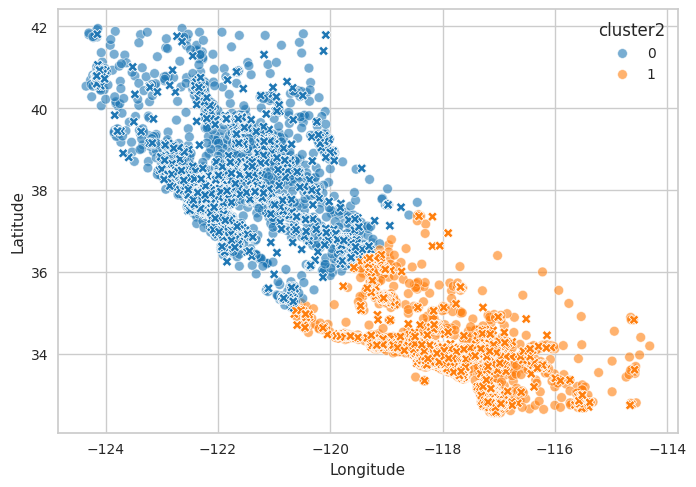

In [12]:
kmeans2 = KMeans(n_clusters=2, random_state=42)
kmeans2.fit(X_train_scaled)
X_train['cluster2'] = kmeans2.labels_
#  Asignamos la predicion de los clusters a los datos Test
test_clusters2 = kmeans2.predict(X_test_scaled)
X_test['cluster2'] = test_clusters2

sns.scatterplot(
    data=X_train,
    x='Longitude',
    y='Latitude',
    hue='cluster2',  
    palette='tab10',
    alpha=0.6
)

sns.scatterplot(
    data=X_test,
    x='Longitude',
    y='Latitude',
    hue='cluster2',
    palette='tab10',
    marker='X',   
    legend=False  
)

Al utilizar K=2 podemos ver que efectivamente se encuentra mejor distribuidos como nos indicaba los metodos anteriores.

# Entrenamos un modelo de clasificacion supervisada

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

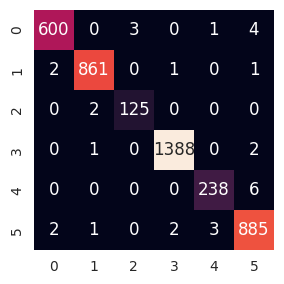

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       608
           1       1.00      1.00      1.00       865
           2       0.98      0.98      0.98       127
           3       1.00      1.00      1.00      1391
           4       0.98      0.98      0.98       244
           5       0.99      0.99      0.99       893

    accuracy                           0.99      4128
   macro avg       0.99      0.99      0.99      4128
weighted avg       0.99      0.99      0.99      4128



In [13]:
# Utilizamos Random Forest para predecir los clusters
df_final = pd.concat([X_train, X_test])
# Variables
X = df_final[["Latitude", "Longitude", "MedInc"]]  # features
y = df_final["cluster"]                            # target (clusters)

# Dividir en train/test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modelo supervisado
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Predicciones
y_pred = rf.predict(X_test)

# Estadísticas
matrix = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(matrix)
plt.figure(figsize = (3, 3))
sns.heatmap(cm_df, annot=True, fmt="d", cbar=False)
plt.tight_layout()
plt.show()
print(classification_report(y_test, y_pred))

El accurracy el del 99% y la presicion tambien es casi del 100%, lo cual es lo esperado, ya que los clusters estan basados en las mismas caracteristicas con las que se entreno el modelo, por ende no hay ninguna caracteristica que nos genere ruido.

# Guardamos los modelos 

In [14]:
joblib.dump(kmeans, "kmeans_model.pkl")

['kmeans_model.pkl']

In [15]:
joblib.dump(rf, "rf_model.pkl")

['rf_model.pkl']